## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())
print('Số ô Income còn thiếu:', customer_data['Income'].isna().sum())

Số ô Income còn thiếu: 0


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [8]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')  # ngày-tháng-năm
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [9]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [10]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (customer_data['AcceptedCmp1'] + customer_data['AcceptedCmp2']
                                 + customer_data['AcceptedCmp3'] + customer_data['AcceptedCmp4']
                                 + customer_data['AcceptedCmp5'])

In [11]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (customer_data['MntWines'] + customer_data['MntFruits']
                             + customer_data['MntMeatProducts'] + customer_data['MntFishProducts']
                             + customer_data['MntSweetProducts'] + customer_data['MntGoldProds'])

#### A4. Phân tích EDA

In [12]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4832.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4479.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4659.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4834.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5008.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5178.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

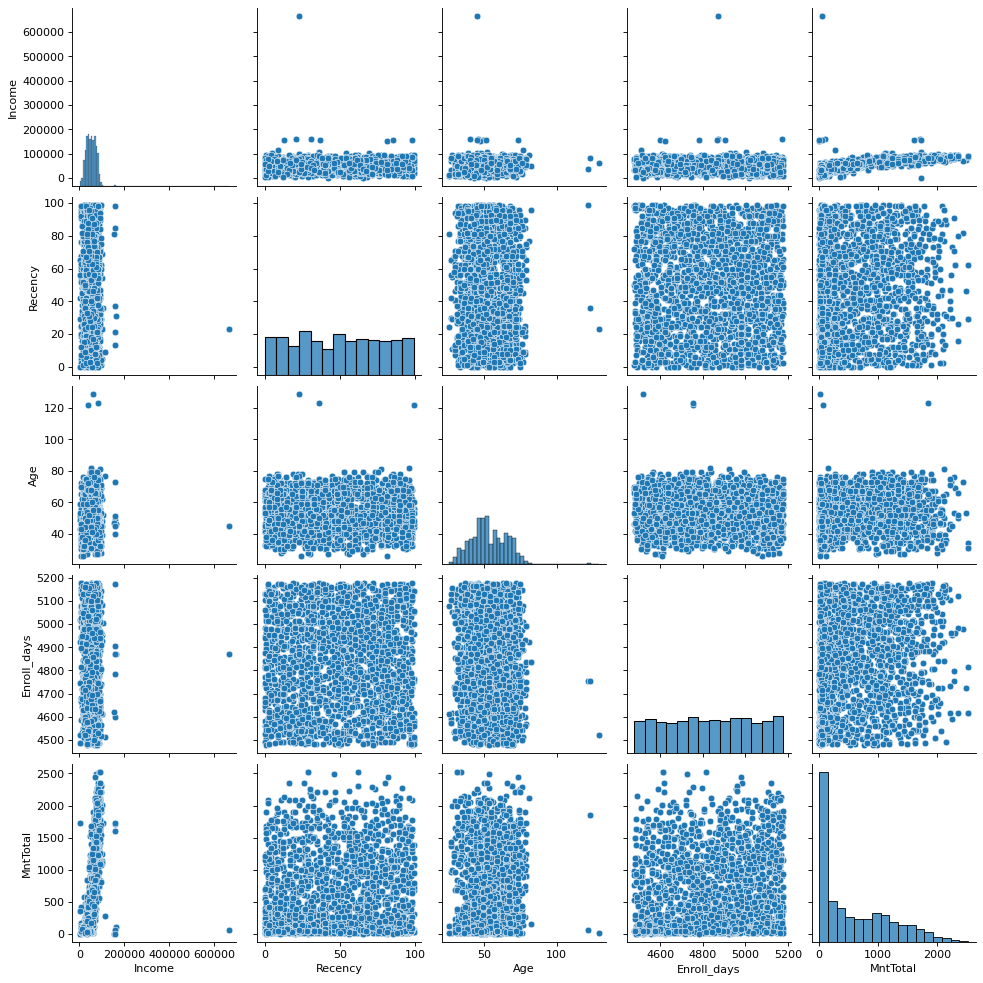

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [15]:
# TODO - xử lý nhiễu (nếu có)
# Nhìn pair plot: có vài khách Age > 100 (năm sinh 1893 - 1900) và 1 khách Income = 666666
# nằm rất xa phần còn lại -> loại bỏ
print('Age >= 100:', (customer_data['Age'] >= 100).sum(), '| Income >= 200000:', (customer_data['Income'] >= 200000).sum())
customer_data = customer_data[(customer_data['Age'] < 100) & (customer_data['Income'] < 200000)].copy()
print('Số dòng sau khi loại nhiễu:', customer_data.shape[0])

Age >= 100: 3 | Income >= 200000: 1
Số dòng sau khi loại nhiễu: 2236


In [16]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [17]:
# TODO
# Sau khi drop, df chỉ còn cột số (Education bị bỏ, Marital_Status đã gộp thành Fam_Size).
# Vẫn kiểm tra: nếu còn cột kiểu loại thì mã hoá bằng LabelEncoder.
from sklearn.preprocessing import LabelEncoder, StandardScaler

cot_loai = df.select_dtypes(exclude='number').columns.tolist()
print('Cột kiểu loại còn lại:', cot_loai)
for c in cot_loai:
    df[c] = LabelEncoder().fit_transform(df[c])

Cột kiểu loại còn lại: []


**Chuẩn hoá các thuộc tính kiểu số**

In [18]:
# TODO
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [19]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,2.240307e-16,-7.149916e-17,1.271096e-17,0.000000,-7.308803e-17,-1.322734e-16,-1.525315e-16,6.514368e-17,1.150342e-15,2.192641e-16,4.766610e-18
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346560e+00,-1.696543e+00,-1.203575e+00,-1.470716,-9.110556e-01,-1.783046e+00,-2.192136e+00,-2.316276e+00,-1.750171e+00,-1.758810e+00,-9.987636e-01
25%,-7.688934e-01,-8.675502e-01,-6.861374e-01,-0.751127,-9.110556e-01,-8.600834e-01,-9.557071e-01,-6.924366e-01,-8.559730e-01,-6.565959e-01,-8.924037e-01
50%,-1.298227e-02,-4.016436e-03,-1.686996e-01,-0.031538,-2.268842e-01,-2.447750e-01,2.807217e-01,-9.417994e-02,1.101605e-02,4.456177e-01,-3.481402e-01
75%,7.620935e-01,8.595173e-01,3.487383e-01,0.688050,4.572872e-01,6.781877e-01,6.928646e-01,8.459377e-01,8.668740e-01,4.456177e-01,7.304157e-01
max,5.158923e+00,1.723051e+00,6.557993e+00,8.243731,8.667344e+00,2.216459e+00,6.050723e+00,2.469777e+00,1.707891e+00,2.650045e+00,3.189157e+00


#### A6. Phân cụm KMeans

In [20]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

inertia: [24596, 17462, 15233, 14278, 13364, 12819, 12279, 11825, 11474, 11132]
K=2: silhouette = 0.275
K=3: silhouette = 0.231
K=4: silhouette = 0.157
K=5: silhouette = 0.144
K=6: silhouette = 0.135


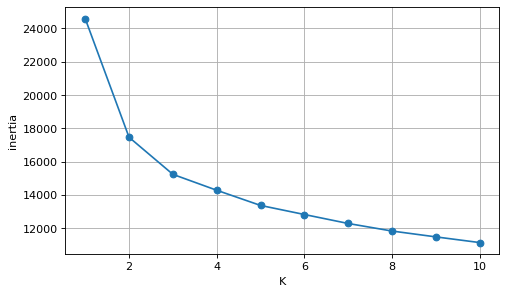

In [21]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
from sklearn.metrics import silhouette_score

ks = list(range(1, 11))
inertias = []
for k in ks:
    model = KMeans(n_clusters=k, n_init=20, random_state=99).fit(df)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

print('inertia:', [round(v) for v in inertias])
for k in range(2, 7):
    s = silhouette_score(df, KMeans(n_clusters=k, n_init=20, random_state=99).fit_predict(df))
    print(f'K={k}: silhouette = {s:.3f}')

Sử dụng thư viện yellowbrick

In [22]:
from yellowbrick.cluster import KElbowVisualizer

In [23]:
# TODO
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(df)
visualizer.show()
print('K do yellowbrick gợi ý:', visualizer.elbow_value_)

**Phân cụm từ kết quả của phương pháp Elbow**

In [24]:
# TODO
# Chọn K=3: inertia giảm mạnh tới K=3 rồi thoải dần, silhouette cao nhất trong các K >= 3
k_best = 3
kmean = KMeans(n_clusters=k_best, n_init=20, random_state=99).fit(df)
print('số điểm mỗi cụm:', np.unique(kmean.labels_, return_counts=True))

số điểm mỗi cụm: (array([0, 1, 2], dtype=int32), array([ 511, 1005,  720]))


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [25]:
from sklearn.decomposition import PCA

In [26]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
pca = PCA()                                  # giữ đủ thành phần để vẽ scree plot ở phần A7
pca_transformed = pca.fit_transform(df)
pca_transformed_2d = pca_transformed[:, :2]  # lấy 2 thành phần chính đầu tiên
print(pca_transformed_2d.shape)

(2236, 2)


**Trực quan hoá kết quả phân cụm**

In [27]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

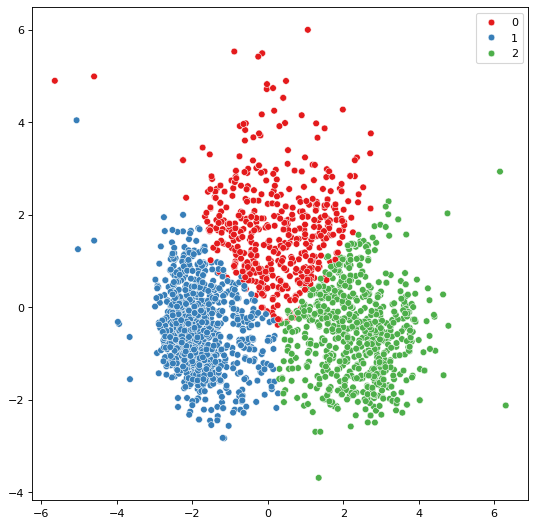

In [28]:
# Trực quan hoá kết quả phân cụm KMeans (K=3) trên không gian pca 2 chiều
visualize_cluster_result(pca_transformed_2d, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [29]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5142,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4592,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4791,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4618,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4640,3,0,422,0


In [30]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

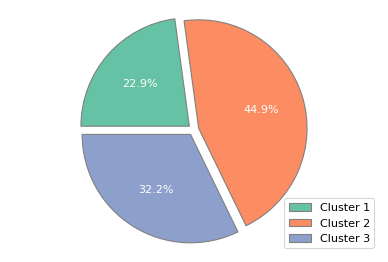

In [31]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

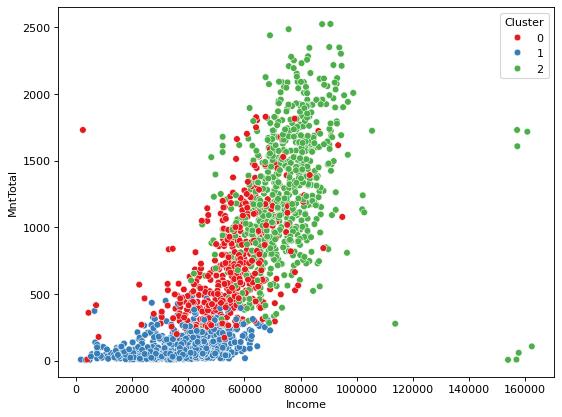

In [32]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

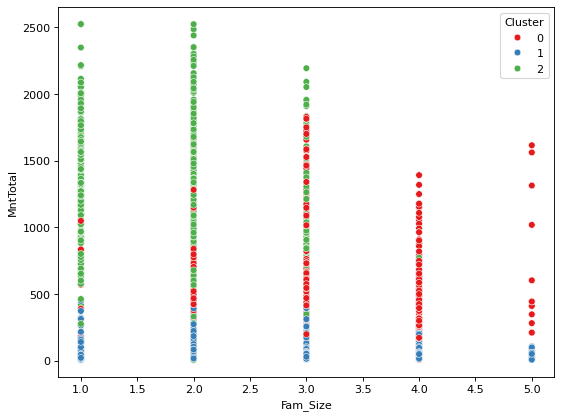

In [33]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

**Phân tích danh mục mua hàng**

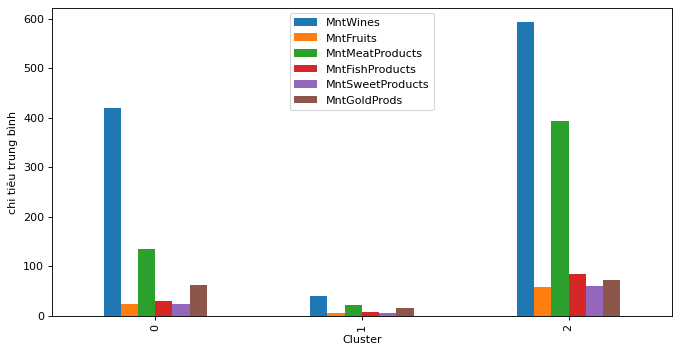

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,419.0,23.9,134.0,30.3,24.3,61.3
1,39.2,5.0,21.5,7.4,5.2,15.4
2,592.4,57.7,393.5,84.7,59.7,71.6


In [34]:
# TODO
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
mnt_by_cluster = kmean_df.groupby('Cluster')[mnt_cols].mean().round(1)

mnt_by_cluster.plot(kind='bar', figsize=(10, 5))
plt.ylabel('chi tiêu trung bình')
plt.show()
mnt_by_cluster

In [35]:
# Hồ sơ trung bình của từng cụm (số gốc) + số khách mỗi cụm
profile = kmean_df.groupby('Cluster')[['Income', 'MntTotal', 'Age', 'Fam_Size', 'Recency',
                                       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
                                       'NumWebVisitsMonth', 'NumDealsPurchases']].mean().round(1)
profile['So_khach'] = kmean_df['Cluster'].value_counts().sort_index()
profile

,Income,MntTotal,Age,Fam_Size,Recency,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,NumDealsPurchases,So_khach
Cluster,,,,,,,,,,,
0,54587.4,692.7,56.5,3.0,48.7,6.6,2.7,7.1,6.5,4.6,511
1,34538.4,93.6,50.4,2.9,49.1,2.0,0.5,3.2,6.4,1.9,1005
2,74418.8,1259.7,54.4,1.9,49.4,5.2,5.6,8.5,3.0,1.4,720


**Nhận xét (KMeans, K=3):**

- **Cụm 2** (720 khách, khoảng 32%): thu nhập cao (~74.4k), chi tiêu rất cao (`MntTotal` ~1260), gia đình nhỏ (`Fam_Size` ~1.9). Mua nhiều qua catalog (5.6) và cửa hàng (8.5), ít vào web (3.0 lượt/tháng), ít mua theo khuyến mãi (1.4). Đây là nhóm khách giá trị cao; rượu vang và thịt chiếm phần lớn chi tiêu (xem biểu đồ danh mục).
- **Cụm 1** (1005 khách, khoảng 45%): thu nhập thấp (~34.5k), chi tiêu rất thấp (`MntTotal` ~94), gần như không mua qua catalog (0.5). Vẫn vào web nhiều (6.4 lượt/tháng) nhưng mua ít.
- **Cụm 0** (511 khách, khoảng 23%): thu nhập và chi tiêu trung bình (~54.6k, ~693), gia đình đông nhất (~3.0 người), mua nhiều qua web (6.6) và là nhóm săn khuyến mãi nhiều nhất (4.6 lần mua ưu đãi).

Về danh mục: cụm 2 chi trung bình 592 cho rượu vang và 394 cho thịt, cụm 0 là 419 và 134 (nhưng chi cho Gold khá cao, 61), còn cụm 1 chi thấp ở mọi danh mục.

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [36]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

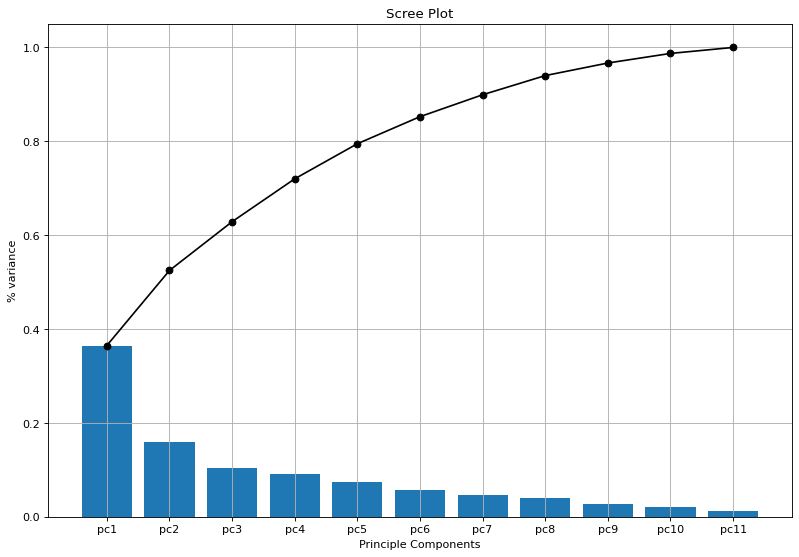

In [37]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [38]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca4 = PCA(n_components=4)
pca_transformed_4d = pca4.fit_transform(df)
print('Phương sai giữ lại với 4 thành phần:', pca4.explained_variance_ratio_.sum().round(3))

Phương sai giữ lại với 4 thành phần: 0.72


In [39]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()
print('K do yellowbrick gợi ý:', visualizer.elbow_value_)

số điểm mỗi cụm: (array([0, 1, 2], dtype=int32), array([ 712, 1006,  518]))
pca 4d    0    1    2
df gốc               
0         5    7  499
1         0  999    6
2       707    0   13


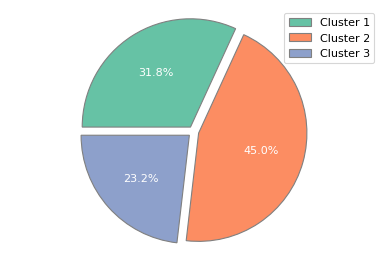

In [40]:
# Phân cụm trên dữ liệu pca 4 chiều. Từ elbow ở trên: inertia gãy ở K=3 rồi thoải dần -> K=3
k_pca = 3
kmean_pca = KMeans(n_clusters=k_pca, n_init=20, random_state=99).fit(pca_transformed_4d)
print('số điểm mỗi cụm:', np.unique(kmean_pca.labels_, return_counts=True))

# So với phân cụm trên dữ liệu gốc (11 đặc trưng): hầu hết khách cùng nhóm (số thứ tự nhãn có thể khác nhau)
print(pd.crosstab(kmean.labels_, kmean_pca.labels_, rownames=['df gốc'], colnames=['pca 4d']))

# Phân bố kết quả phân cụm
visualize_cluster_distribution(kmean_pca.labels_)

In [41]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean_pca.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5142,1,0,1617,0
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4592,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4791,2,0,776,0
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4618,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4640,3,0,422,2


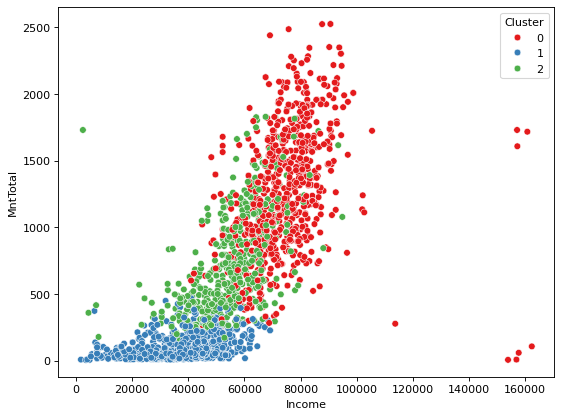

In [42]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

**Nhận xét (PCA 4 chiều + KMeans):**

- 4 thành phần chính giữ lại khoảng 72% phương sai (nằm trong khoảng 70 - 80% yêu cầu), nên số chiều giảm từ 11 xuống 4 mà mất ít thông tin.
- Elbow trên dữ liệu pca cũng gãy ở K=3, cho 3 cụm (712, 1006 và 518 khách). Bảng crosstab với kết quả trên dữ liệu gốc cho thấy gần như toàn bộ khách (khoảng 98%) rơi vào cùng nhóm, chỉ khác số thứ tự nhãn.
- Trên scatter Income - MntTotal, ba cụm sắp thành ba tầng theo MntTotal (và Income): chi tiêu thấp, trung bình, cao.

Vậy PCA giúp trực quan hoá và giảm chiều mà không làm thay đổi cấu trúc cụm.

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [43]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [44]:
len(df.columns)

11

In [45]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot: khoảng cách tới láng giềng thứ n_neighs (cột cuối), sắp xếp tăng dần
    distances = np.sort(distances[:, -1])
    plt.plot(distances)

    return distances

phân vị 50/80/90 của k-distance: [1.92 2.26 2.48]


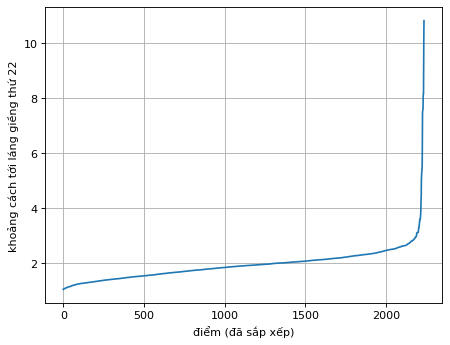

In [46]:
# Dữ liệu df đầy đủ (11 đặc trưng): min_samples ~ 2 * số chiều
min_pts = 2 * len(df.columns)
distances = knee_plot(min_pts, df)
plt.xlabel('điểm (đã sắp xếp)')
plt.ylabel(f'khoảng cách tới láng giềng thứ {min_pts}')
plt.grid(True)
plt.show()
print('phân vị 50/80/90 của k-distance:', np.percentile(distances, [50, 80, 90]).round(2))

In [47]:
# Khuỷu nằm quanh 2.5 -> eps = 2.5
db_full = DBSCAN(eps=2.5, min_samples=min_pts).fit(df)
labels_full = db_full.labels_
print('số cụm:', len(set(labels_full)) - (1 if -1 in labels_full else 0), '| số nhiễu:', (labels_full == -1).sum())
print(np.unique(labels_full, return_counts=True))

số cụm: 1 | số nhiễu: 35
(array([-1,  0]), array([  35, 2201]))


**Sử dụng PCA thu giảm số chiều --> phân cụm**

phân vị 50/80/90 của k-distance: [0.71 0.89 1.01]
số cụm: 1 | số nhiễu: 73
(array([-1,  0]), array([  73, 2163]))


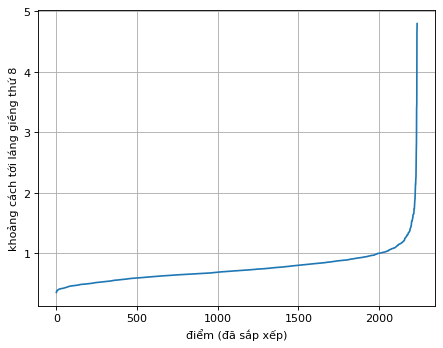

In [48]:
# Dữ liệu pca 4 chiều: min_samples = 2 * 4 = 8
min_pts_pca = 2 * pca_transformed_4d.shape[1]
distances_pca = knee_plot(min_pts_pca, pca_transformed_4d)
plt.xlabel('điểm (đã sắp xếp)')
plt.ylabel(f'khoảng cách tới láng giềng thứ {min_pts_pca}')
plt.grid(True)
plt.show()
print('phân vị 50/80/90 của k-distance:', np.percentile(distances_pca, [50, 80, 90]).round(2))

# Khuỷu nằm quanh 1.0 -> eps = 1.0
db_pca = DBSCAN(eps=1.0, min_samples=min_pts_pca).fit(pca_transformed_4d)
labels_pca = db_pca.labels_
print('số cụm:', len(set(labels_pca)) - (1 if -1 in labels_pca else 0), '| số nhiễu:', (labels_pca == -1).sum())
print(np.unique(labels_pca, return_counts=True))

**Chia nhỏ đặc trưng**

In [49]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

phân vị 50/80/90 của k-distance: [0.2  0.27 0.33]
số cụm: 1 | số nhiễu: 165


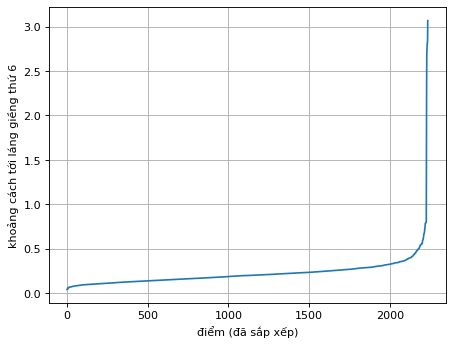

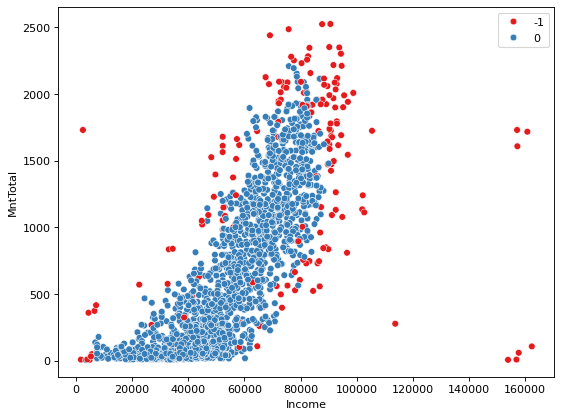

In [50]:
# Chỉ dùng 3 đặc trưng Income, MntTotal, Enroll_days: min_samples = 2 * 3 = 6
min_pts_sub = 2 * sub_df.shape[1]
distances_sub = knee_plot(min_pts_sub, sub_df)
plt.xlabel('điểm (đã sắp xếp)')
plt.ylabel(f'khoảng cách tới láng giềng thứ {min_pts_sub}')
plt.grid(True)
plt.show()
print('phân vị 50/80/90 của k-distance:', np.percentile(distances_sub, [50, 80, 90]).round(2))

# Khuỷu nằm quanh 0.3 -> eps = 0.3
db_sub = DBSCAN(eps=0.3, min_samples=min_pts_sub).fit(sub_df)
labels_sub = db_sub.labels_
print('số cụm:', len(set(labels_sub)) - (1 if -1 in labels_sub else 0), '| số nhiễu:', (labels_sub == -1).sum())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=customer_data['Income'].values, y=customer_data['MntTotal'].values,
                hue=labels_sub, palette='Set1')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.show()

**Nhận xét DBSCAN (A9):** cả ba cấu hình (11 đặc trưng: eps=2.5, min_samples=22; PCA 4 chiều: eps=1.0, min_samples=8; 3 đặc trưng Income - MntTotal - Enroll_days: eps=0.3, min_samples=6) chỉ cho **1 cụm lớn** cùng một số điểm nhiễu (35, 73 và 165 điểm). Khi thử hạ eps để tách nhỏ hơn, kết quả nhảy từ 1 cụm sang vài cụm rất nhỏ và rất nhiều điểm nhiễu.

Lý do là khách hàng phân bố liên tục thành một đám mây, không có vùng thưa rõ rệt giữa các nhóm, trong khi DBSCAN tách cụm dựa trên các vùng thưa. KMeans (chia theo khoảng cách tới tâm) cho ba nhóm khách có ý nghĩa kinh doanh hơn ở bộ dữ liệu này.

### B. Dữ liệu taxi 

In [51]:
import pandas as pd

In [52]:
df = pd.read_csv('data/taxi_data.csv')
df = df.dropna().reset_index(drop=True)   # file có 1 dòng trống ở cuối
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [53]:
import folium, re

In [54]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='CartoDB positron', zoom_start=10)

In [55]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

phân vị 50/80/90 của k-distance: [0.003 0.027 0.045]


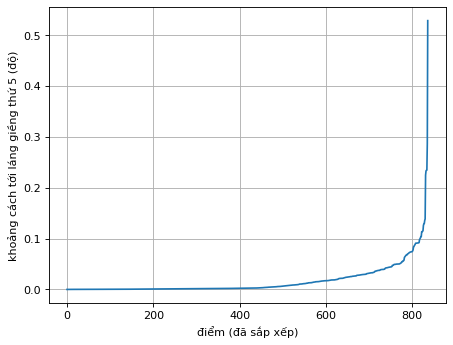

In [56]:
# Knee plot để ước lượng eps
distances_taxi = knee_plot(5, X)
plt.xlabel('điểm (đã sắp xếp)')
plt.ylabel('khoảng cách tới láng giềng thứ 5 (độ)')
plt.grid(True)
plt.show()
print('phân vị 50/80/90 của k-distance:', np.percentile(distances_taxi, [50, 80, 90]).round(3))

In [57]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [58]:
# Sử dụng DBSCAN để phân cụm
# Toạ độ để nguyên đơn vị độ (1 độ ~ 100 km); khuỷu k-distance nằm quanh 0.02 (~ 2 km)
dbscan_taxi = DBSCAN(eps=0.02, min_samples=5).fit(X)
df['Cluster'] = dbscan_taxi.labels_
df['Color'] = df['Cluster'].map(lambda c: 'black' if c == -1 else colors[c])   # nhiễu: màu đen

print('số cụm:', df['Cluster'].nunique() - (1 if -1 in df['Cluster'].values else 0))
print('số điểm nhiễu:', (df['Cluster'] == -1).sum())
print('5 cụm lớn nhất:')
print(df.loc[df['Cluster'] != -1, 'Cluster'].value_counts().head())

số cụm: 51
số điểm nhiễu: 181
5 cụm lớn nhất:
Cluster
9    77
3    64
1    37
0    31
4    26
Name: count, dtype: int64


In [59]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='CartoDB positron',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m

In [60]:
create_map('Cluster', 'Color', 'DBSCAN trên toạ độ taxi rank (eps=0.02, min_samples=5), nhiễu màu đen')

DBSCAN trên toạ độ taxi rank (eps=0.02, min_samples=5), nhiễu màu đen


**Nhận xét:** với `eps=0.02` độ (khoảng 2 km) và `min_samples=5`, DBSCAN tìm được **51 cụm** taxi rank và **181 điểm nhiễu** (khoảng 21.6% trong 837 điểm). Cụm lớn nhất có 77 điểm, các cụm tiếp theo có 64, 37, 31 và 26 điểm. Cụm là những khu vực có nhiều điểm taxi sát nhau; nhiễu (màu đen trên bản đồ) là các điểm nằm riêng lẻ ở vùng thưa.

Khác k-Means, không cần chọn trước số cụm và cụm có thể mang hình dạng bất kỳ theo mật độ điểm. Bản đồ hiển thị khi chạy ô `create_map` ở trên (cần cài `folium`).